# Introduction

The increasing prevalence of social media use among students has raised concerns about its potential effects on academic performance and mental health. Social media platforms are widely used for communication, entertainment, and information sharing, but excessive use may lead to distractions, interpersonal conflict, and symptoms associated with social media addiction. As a result, understanding how patterns of social media use relate to student outcomes has become an important area of study.

This project analyzes a student social media dataset to examine how different patterns of social media use are associated with academic performance and mental health outcomes. The dataset includes variables related to social media behavior, such as average daily usage, most-used platforms, conflicts caused by social media, and whether students perceive themselves as addicted to social media. In addition, demographic characteristics, including age, gender, education level, and country of residence, are included to explore whether these factors influence the relationship between social media use and student outcomes.

Through statistical analysis, this study aims to identify potentially harmful patterns of social media use that may be associated with poorer academic performance and negative mental health indicators. The analysis will also examine whether these relationships differ across demographic groups, such as age, gender, education level, and geographic region.

The primary research question is whether higher levels of social media usage, conflict related to social media, or self-perceived addiction are associated with poorer mental health among students. It is hypothesized that greater daily social media use and higher indicators of conflict or addiction will be associated with poorer mental health outcomes. Additionally, it is expected that demographic factors—particularly education level—may moderate these relationships, potentially reducing the strength of harmful associations among students at higher education levels.

**Research Question 1:** Are higher levels of social media use, conflict, or self-percieved addiction associated with poorer mental health status among students?

**Research Question 2:** Do associations of social media, conflict, and academic performance differ across demographic subgroups (age, gender, education level, and country group)?


In [60]:
#Load Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
#Load Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
#Load Source Code
import data_cleaning as dc
import exploratory_analysis as ea
import modeling

# Dataset Description

Describe Data

In [63]:
#Load Data
df = pd.read_csv('Students Social Media Addiction.csv')
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


# Preprocessing

In [64]:
#NA Removal
df.isna().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

There appears to be no null or missing values in the dataset that must be removed. Additionally, after manually examining all 705 respondants, all answers appear to have be consistent and truthfull. 

In [65]:
# Outlier Removal
df_clean = dc.clean_data(df)
df_clean.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000
mean,353.096866,20.659544,4.913533,6.875926,6.226496,2.850427,6.435897
std,203.541208,1.397793,1.239162,1.116842,1.100504,0.951982,1.575768
min,1.000000,18.000000,2.000000,4.000000,4.000000,0.000000,3.000000
25%,177.250000,19.250000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,352.500000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.750000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.300000,9.600000,8.000000,5.000000,9.000000


3 Outliers have been removed based on a 1.5 * IQR method to ensure data accuracy and a roughly normal distribution. 

# Exploratory Analysis

### Mental Health Score Distribution

Summary Statistics:
count    702.000000
mean       6.226496
std        1.100504
min        4.000000
25%        5.000000
50%        6.000000
75%        7.000000
max        8.000000
Name: Mental_Health_Score, dtype: float64


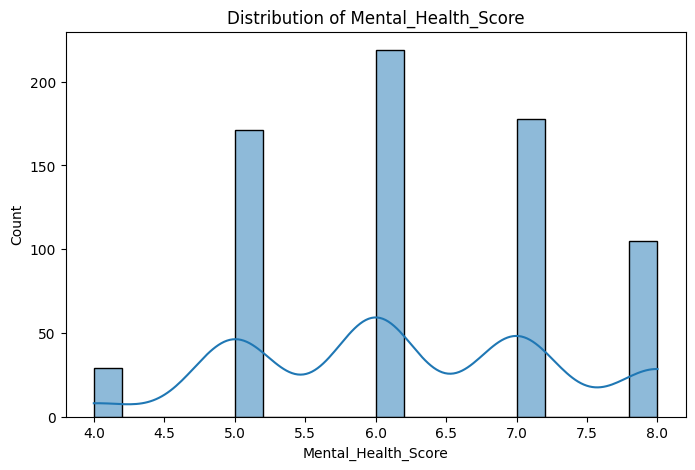

In [66]:
ea.summarize_variable(df_clean,"Mental_Health_Score")

Mental Health Scores are centered around a value of 6.23 with a minimum value of 4 and a maximum value of 8. Additionally, the median of 6 is relatively close to the mean value of 6.23 implying little to no skew in either direction and shows that the distribution appears to be roughly normal.

### Correlation Between Usage and Mental Health

Pearson correlation between 'Avg_Daily_Usage_Hours' and 'Mental_Health_Score': -0.801


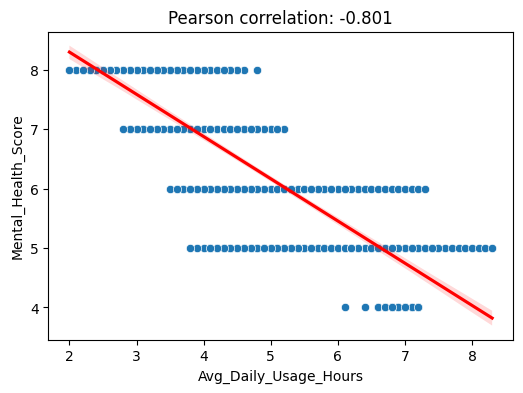

np.float64(-0.8007189310136091)

In [67]:
ea.correlate(df_clean,"Avg_Daily_Usage_Hours","Mental_Health_Score")

There appears to be an incredibly strong, negative correlation between average daily usage of social media (no matter the platform) and lower mental health scores with a pearson correlation of -0.801. This strong correlation demonstrates that higher usage is related to worse mental health. This relationship will be further explored in model building.

### Correlation Between Addiction and Mental Health

Pearson correlation between 'Addicted_Score' and 'Mental_Health_Score': -0.945


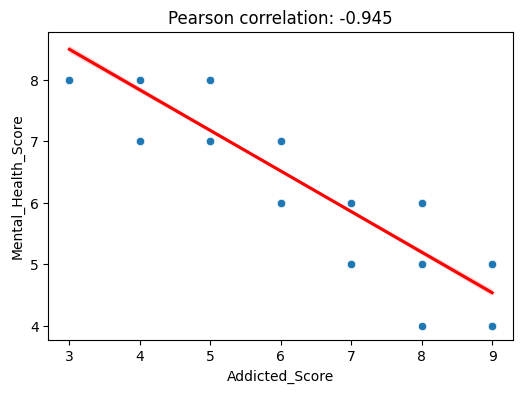

np.float64(-0.9446181789142625)

In [68]:
ea.correlate(df_clean,"Addicted_Score","Mental_Health_Score")

Similar to the correlation calculated between mental health score and average social media usage, social media addiction score and mental health are even more strongly negatively correlated with a pearson value of -0.945. This further supports the hypothesis that greater consumption of social media negatively impacts social media.

### Correlation Between Age and Mental Health

Pearson correlation between 'Age' and 'Mental_Health_Score': 0.153


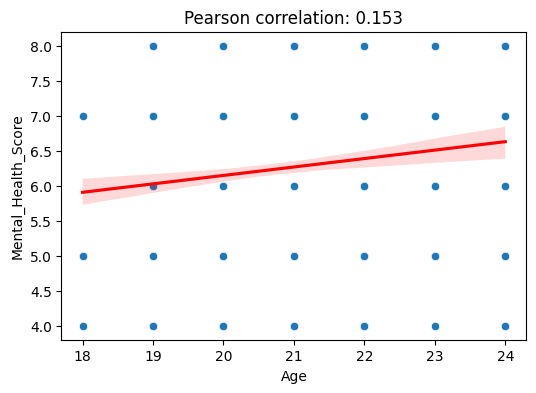

np.float64(0.15313700056971952)

In [69]:
ea.correlate(df_clean,"Age","Mental_Health_Score")

There appears to be a slight, positive correlation between age and mental health score shown by a pearson correlation of 0.153. However, this relationship does not appear to be strong and most likely occured by random chance rather than statistical significance. Thus, age will not be included in the final regression model.

### Platform Usage Patterns

Comparing 'Mental_Health_Score' across 12 groups of 'Most_Used_Platform': ['Facebook', 'Instagram', 'KakaoTalk', 'LINE', 'LinkedIn', 'Snapchat', 'TikTok', 'Twitter', 'VKontakte', 'WeChat', 'WhatsApp', 'YouTube']


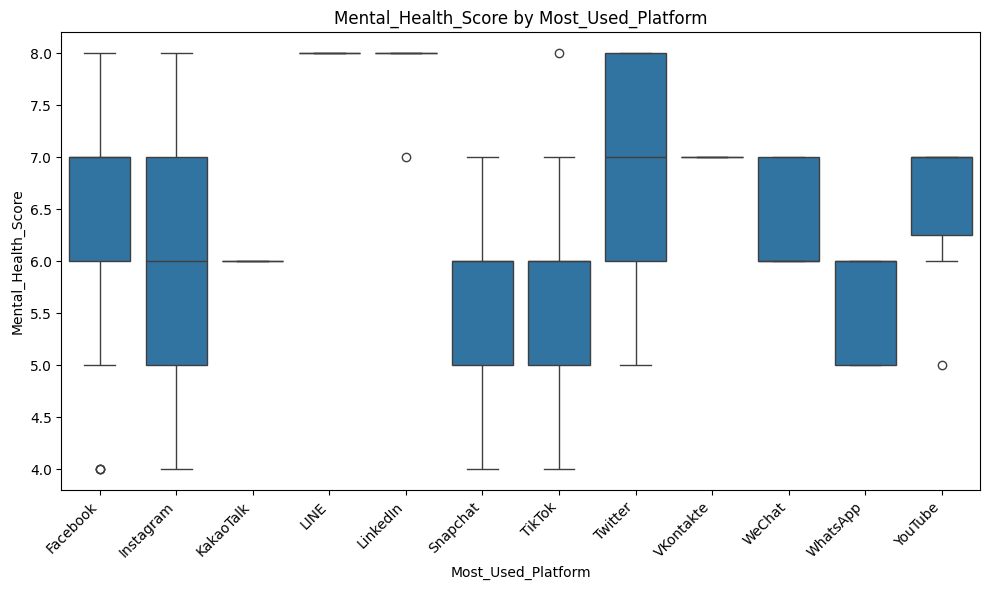

One-way ANOVA result: F = 22.109, p = 0.0000


(np.float64(22.10914816748988), np.float64(7.354057944966376e-39))

In [70]:
ea.compare(df_clean,"Mental_Health_Score","Most_Used_Platform")

Based on the ANOVA test conducted, there appears to be a statically significant difference in mental health scores based on the most used social media platform with an F-statistic of 22.11 and a p-value of 0.00. As seen in the visual, individuals that use Twitter the most tend to have the greatest mental health scores while individuals that use Snapchat and TikTok the most have the lowest mental health scores. This staticially significant relationship between most used platform and mental health scores may create an interaction effect with average hours spent and should be explored in the regression model.

### Academic Impact Patterns

Comparing 'Mental_Health_Score' across 2 groups of 'Affects_Academic_Performance': ['No', 'Yes']


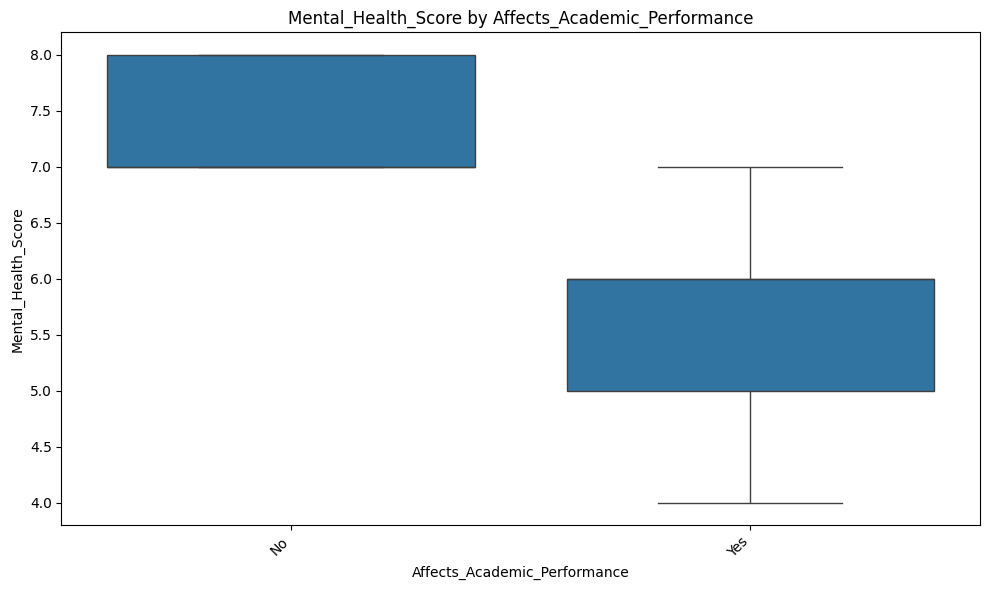

T-test (Welch) result: t = 40.280, p = 0.0000


(np.float64(40.280172648122665), np.float64(4.1390965638271877e-181))

In [71]:
ea.compare(df_clean,"Mental_Health_Score","Affects_Academic_Performance")

Based on the t-test  conducted, there does appear to be a staticially significant difference in mental health scores based on whether social media impacts and individuals academic performance with a T-statistic of 40.28 and a p-value of 0.00. As seen by the boxplot comparing both, the difference appears to be incredibly strong with individuals that answered "Yes" to their academics being impacted having much lower average mental health scores. This analysis demonstrates that individuals with higher amounts of social media usage that believe this social media usage is impacting their academics are more likely to have worse mental health than individuals that do not believe their social media usage is impacting their academic performance.

### Demographic Analysis

Comparing 'Mental_Health_Score' across 2 groups of 'Gender': ['Female', 'Male']


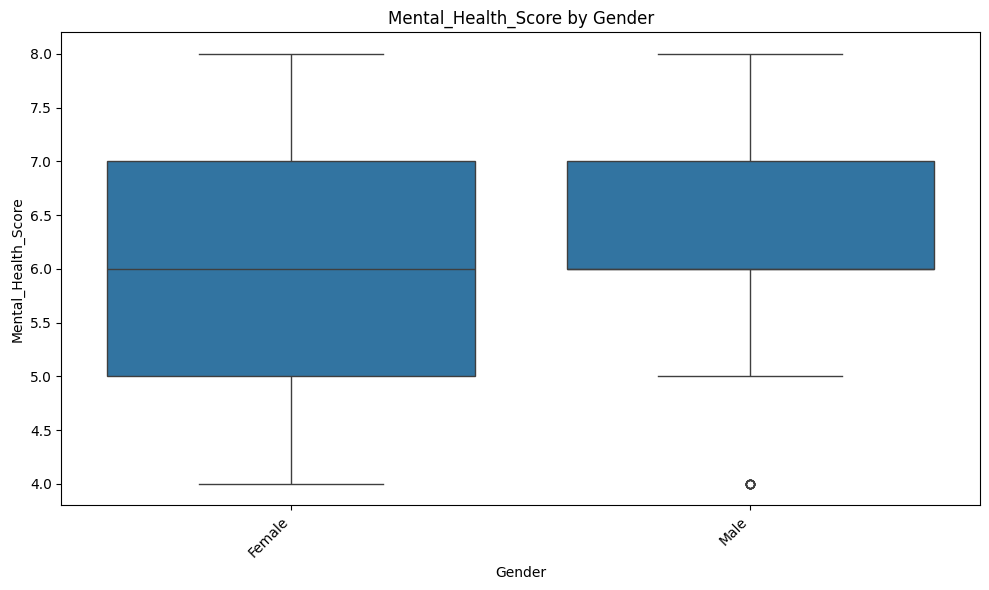

T-test (Welch) result: t = -1.063, p = 0.2880


(np.float64(-1.0632662101494033), np.float64(0.2880339661337769))

In [72]:
ea.compare(df_clean,"Mental_Health_Score","Gender")

Based on the t-test conducted to determine whether there is a relationship between gender and mental health score, there does not appear to be a staticially significant relationship between these variables with a p-value of 0.29. Thus, gender does not appear to have a significant impact on mental health and should not be included in the final model.

Comparing 'Mental_Health_Score' across 3 groups of 'Academic_Level': ['Graduate', 'High School', 'Undergraduate']


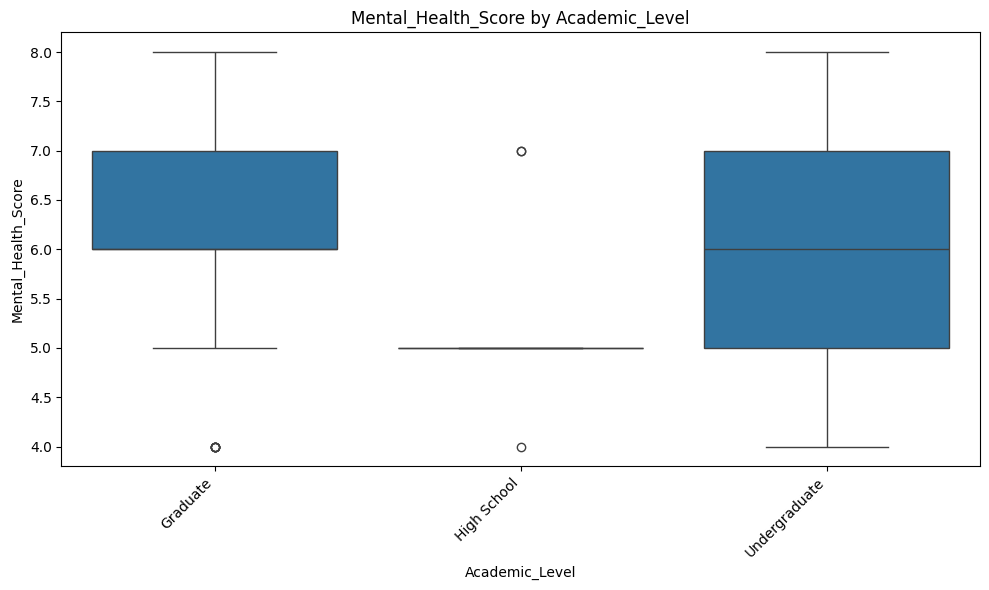

One-way ANOVA result: F = 17.432, p = 0.0000


(np.float64(17.4318416160411), np.float64(4.0944156419009705e-08))

In [73]:
ea.compare(df_clean,"Mental_Health_Score","Academic_Level")

Based on the ANOVA test, there appears to be a staticially significant relationship between mental health scores and academic level shown by the F-statistic of 17.43 and p-value of 0.00. This difference can also be seen in the visual with graduate students having the highest average mental health score and high school students having the lowest average. While this realtionship is statistically significant, graduate and undergraduate students do not appear to differ much and thus, this relationship will be examined further in regression model building to determine which of the 3 groups should be included in the model as dummies.

# Model Building

### Mental Health Multiple Linear Regression Model

Based on the initial exploratory analysis and logical selection, the following variables were found to have relation to mental health scores: academic level, average daily usage, most used platform, affects academic performance, and sleep hours per night. 

However, most used platform and sleep hours per night were ommited from the data. Most used platforms was ommited due to the sheer number of platforms that would need to be included as dummy variables and sleep hours per night was ommited because it was not related to social media usage enough and may have skewed the data away from the primary goal of comparing social media usage with mental health scores.

Thus, the regression model building began with the following variables: academic level, average daily usage, and affect academic performance. The model was adapted as modeling was done to create the best performing model.

# Analysis

Explain Analysis

# Conclusion

Explain Conclusion